# Movie Streaming Bandit Problem
## Action-Value Estimation with Sample Average Method
### Ana Sofia Renteria Palomares

---

## Scenario Description

A movie streaming platform wants to build a recommendation agent that learns which genre of movie to suggest to a user in order to maximize engagement.

### Problem Setup

- **Actions (arms):** 10 movie genres — *Action, Comedy, Drama, Horror, Romance, Sci-Fi, Thriller, Animation, Documentary, Fantasy*
- **Reward:** The percentage of the movie watched by the user, a continuous value in [0, 1].
  - A reward of `1.0` means the user watched the entire movie.
  - A reward of `0.0` means the user stopped immediately.
- **Reward Distribution:** Each genre has a stationary normal distribution with a fixed mean  and shared standard deviation $\sigma = 0.15$. Rewards are clipped to $[0, 1]$.
- **Objective:** The agent must learn which genre leads to the highest average watch-through rate.


In [21]:
# Imports

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"



random.seed(42)
np.random.seed(42)

---
## 1. Stationary Reward Distributions

Each genre has a fixed (stationary) normal distribution. These distributions are unknown to the agent — they represent the true engagement level of each genre.

In [22]:
# Genre configuration — True distributions (hidden from agent)
genres = ["Action", "Comedy", "Drama", "Horror", "Romance",
          "Sci-Fi", "Thriller", "Animation", "Documentary", "Fantasy"]

true_means = [0.65, 0.72, 0.58, 0.45, 0.61, 0.70, 0.68, 0.80, 0.40, 0.55]
true_std   = 0.15   # Shared standard deviation for all genres
n_genres   = len(genres)
optimal_action = int(np.argmax(true_means))  # Animation (index 7)
print("Genre True Means (hidden from agent):")
for i in range(len(genres)):
    print(f"  {genres[i]}: mean = {true_means[i]:.2f}")
print(f"\nOptimal genre: {genres[optimal_action]} (mean = {true_means[optimal_action]:.2f})")

Genre True Means (hidden from agent):
  Action: mean = 0.65
  Comedy: mean = 0.72
  Drama: mean = 0.58
  Horror: mean = 0.45
  Romance: mean = 0.61
  Sci-Fi: mean = 0.70
  Thriller: mean = 0.68
  Animation: mean = 0.80
  Documentary: mean = 0.40
  Fantasy: mean = 0.55

Optimal genre: Animation (mean = 0.80)


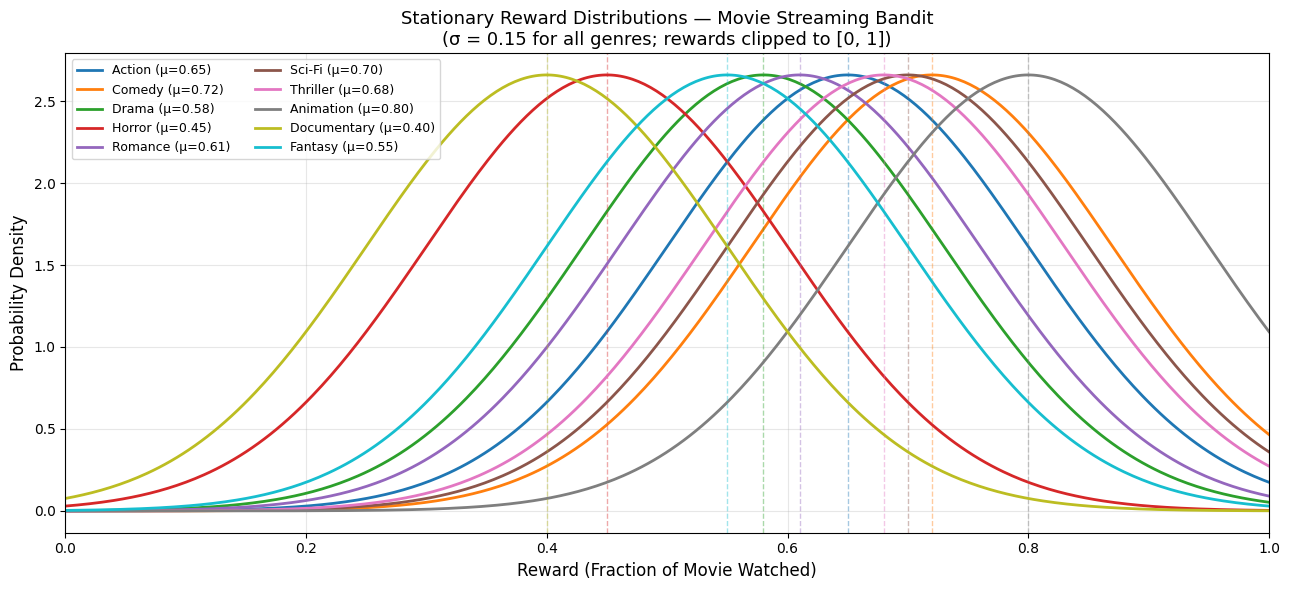

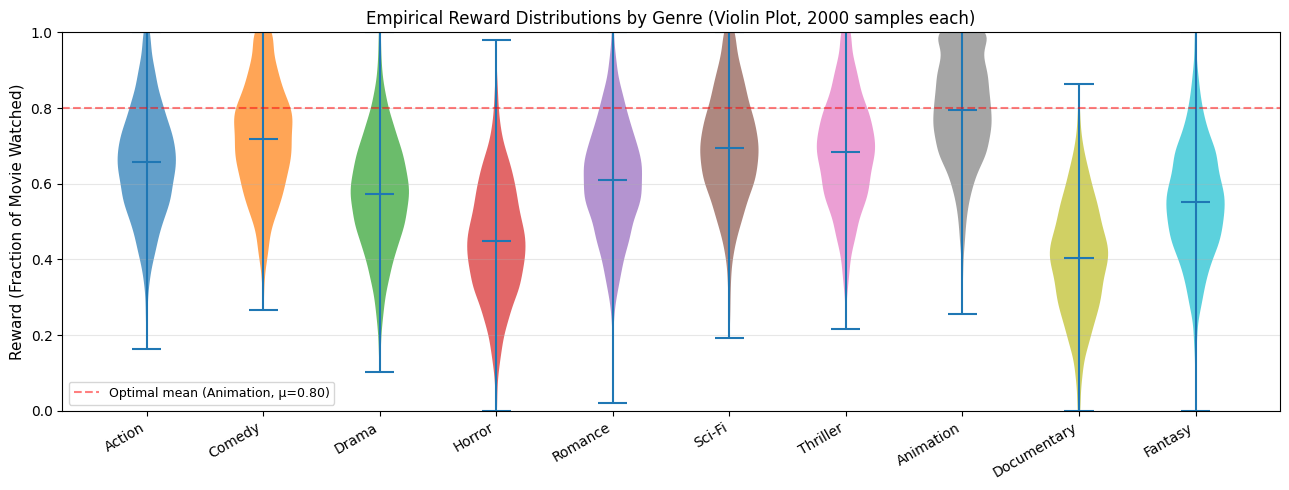

In [23]:
# Plot: Stationary Reward Distributions for all 10 genres
# Shows the normal distribution for each genre

x = np.linspace(0, 1, 400)

fig, ax = plt.subplots(figsize=(13, 6))

colors = plt.cm.tab10(np.linspace(0, 1, n_genres))

for i, (genre, mu, color) in enumerate(zip(genres, true_means, colors)):
    sigma = true_std
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, pdf, label=f"{genre} (μ={mu:.2f})", color=color, linewidth=2)
    ax.axvline(mu, color=color, linestyle='--', alpha=0.4, linewidth=1)

ax.set_xlabel("Reward (Fraction of Movie Watched)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("Stationary Reward Distributions — Movie Streaming Bandit\n"
             "(σ = 0.15 for all genres; rewards clipped to [0, 1])", fontsize=13)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Violin plot — shows empirical reward samples
samples = [np.clip(np.random.normal(mu, true_std, 2000), 0, 1) for mu in true_means]

fig, ax = plt.subplots(figsize=(13, 5))
parts = ax.violinplot(samples, positions=range(n_genres), showmeans=True, showmedians=False)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax.set_xticks(range(n_genres))
ax.set_xticklabels(genres, rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Reward (Fraction of Movie Watched)", fontsize=11)
ax.set_title("Empirical Reward Distributions by Genre (Violin Plot, 2000 samples each)", fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(true_means[optimal_action], color='red', linestyle='--', alpha=0.5,
           label=f'Optimal mean (Animation, μ={true_means[optimal_action]:.2f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Interpretation

The chart shows the probability density of the watch-through rate for each of the 10 movie genres. The x-axis represents the percentage of the movie watched by the user (0 to 1), and the y-axis represents the probability density.

**Key observations:**
- **Animation** (μ = 0.80) has the distribution shifted furthest to the right, indicating it is the genre with the highest expected engagement — it is the **optimal action**.
- Documentary (μ = 0.40) and Horror (μ = 0.45) are positioned furthest to the left, marking the genres with the lowest average engagement.
- All distributions share the same standard deviation (σ = 0.15), so they differ only in their mean.
- The high degree of overlap between curves reflects that the agent cannot identify the best genre from a single observation; it must explore and accumulate samples to correctly estimate the true means.

---
## 3. Agent 1 — Sample Average Method with Random Selection Policy (random exploration)

Indication: create your first agent that estimates action-values using the sample average method with a random selection policy (random exploration). You must present the following plots for 500, 1000, 5000 and 10000 simulation steps.

a. Numbers of times each action was tried.
b. Estimation of action values over time simulation steps.
c. Accumulated reward over time simulation steps.
d. Percentage of optimal action for 2000 runs.

In [24]:
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots


genre_actions = ["Action", "Comedy", "Drama", "Horror", "Romance",
                 "Sci-Fi", "Thriller", "Animation", "Documentary", "Fantasy"]


true_means = [0.65, 0.72, 0.58, 0.45, 0.61, 0.70, 0.68, 0.80, 0.40, 0.55]


optimal_index = true_means.index(max(true_means))


COLORS = [
    "#f97316", "#22d3ee", "#a78bfa", "#f43f5e", "#86efac",
    "#fbbf24", "#60a5fa", "#e879f9", "#34d399", "#fb923c"
]


In [25]:

def simulate(steps):

    
    q_values     = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

   
    q_values_history  = []  
    acum_reward_total = []  
    total_reward      = 0

    
    for t in range(steps):

        
        selected_index = random.randint(0, 9)
        action = genre_actions[selected_index]

        
        r = random.random()
        if r < true_means[selected_index]:
            reward = 1
        else:
            reward = 0

       # agent update
        counts[selected_index]       += 1
        acum_rewards[selected_index] += reward
        total_reward                 += reward

        # SAMPLE AVERAGE METHOD: Q(a) = sum_rewards(a) / times_selected(a)
       
        q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]

        # Save a copy of the current state for plotting
        # (q_values[:] creates a copy of the list)
        q_values_history.append(q_values[:])
        acum_reward_total.append(total_reward)

    
    print(f"\n[{steps} steps]")
    print(f"Final Q-values: {q_values}")
    print(f"Count: {counts}")
    print(f"Accum Rewards: {acum_rewards}")

    return q_values, counts, acum_rewards, q_values_history, acum_reward_total






In [26]:
# Computes the % of times the optimal action was selected at each step,
# averaged over n_runs=2000 independent runs.
def compute_optimal_pct(steps, n_runs=2000):

    # optimal_counts[t] = how many of the 2000 runs selected
    # the optimal action exactly at step t
    optimal_counts = [0] * steps

    for _ in range(n_runs):
        for t in range(steps):
            selected_index = random.randint(0, 9)
            if selected_index == optimal_index:
                optimal_counts[t] += 1

    # Convert to percentage
    return [c / n_runs * 100 for c in optimal_counts]






In [27]:
def plot_scenario(steps):
    q_values, counts, acum_rewards, q_values_history, acum_reward_total = simulate(steps)
    optimal_pct = compute_optimal_pct(steps)

    xs_accum = list(range(1, len(acum_reward_total) + 1))
    ys_accum = acum_reward_total
    xs_opt   = list(range(1, len(optimal_pct) + 1))
    ys_opt   = optimal_pct

    # stride is used to downsample q_values_history for plot b
    stride = max(1, steps // 300)
    xs_q   = list(range(1, steps + 1, stride))

    # ── 2x2 figure with the 4 assignment plots ──
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "a. Number of times each action was tried",
            "b. Estimation of action values over time",
            "c. Accumulated reward over time",
            "d. Percentage of optimal action (2000 runs)"
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10
    )

    # ── Plot a: Action counts ────────────────
    # Shows how many times the agent chose each genre.
    # With a random policy we expect a uniform distribution (~steps/10 per genre).
    # The optimal bar (Animation) is highlighted in pink.
    bar_colors = [
        "#e879f9" if i == optimal_index else COLORS[i]
        for i in range(len(genre_actions))
    ]
    fig.add_trace(go.Bar(
        x=genre_actions,
        y=counts,
        marker=dict(color=bar_colors, line=dict(color="rgba(255,255,255,0.13)", width=1), opacity=0.88),
        hovertemplate="<b>%{x}</b><br>Count: %{y}<extra></extra>",
        showlegend=False
    ), row=1, col=1)

    # ── Plot b: Q-value evolution ─────────────
    # Shows how the Q(a) estimate for each genre gradually
    # stabilizes around the true mean (dotted lines).
    # With more steps, solid lines converge to dotted ones.
    for i, genre in enumerate(genre_actions):
        ys_q = [q_values_history[t][i] for t in range(0, steps, stride)]

        # Solid line = agent's estimate (Q-value)
        fig.add_trace(go.Scatter(
            x=xs_q, y=ys_q,
            mode="lines",
            name=genre,
            line=dict(color=COLORS[i], width=2.5 if i == optimal_index else 1.2),
            opacity=1 if i == optimal_index else 0.75,
            hovertemplate=f"<b>{genre}</b><br>Step: %{{x}}<br>Q: %{{y:.4f}}<extra></extra>",
            legendgroup=genre,
            showlegend=True
        ), row=1, col=2)

        # Dotted line = true mean (hidden from agent, visible to us)
        fig.add_trace(go.Scatter(
            x=[xs_q[0], xs_q[-1]],
            y=[true_means[i], true_means[i]],
            mode="lines",
            line=dict(color=COLORS[i], width=1, dash="dot"),
            opacity=0.3,
            hoverinfo="skip",
            legendgroup=genre,
            showlegend=False
        ), row=1, col=2)

    # ── Plot c: Accumulated reward ──────────────
    # Total sum of "likes" accumulated by the agent.
    # The slope reflects the average reward rate.
    # With random policy: slope ≈ avg(true_means) ≈ 0.614
    fig.add_trace(go.Scatter(
        x=xs_accum, y=ys_accum,
        mode="lines",
        name="Accum. Reward",
        line=dict(color="#34d399", width=2),
        fill="tozeroy",
        fillcolor="rgba(52, 211, 153, 0.12)",
        hovertemplate="Step: %{x}<br>Total Reward: %{y}<extra></extra>",
        showlegend=False
    ), row=2, col=1)

    # ── Plot d: % optimal action ───────────────────
    # Average over 2000 independent runs: how often
    # did the agent select the optimal action (Animation) at each step?
    # With random policy it oscillates around 10% (1/10 actions).
    # If we used a greedy policy, this value would increase over time.
    fig.add_trace(go.Scatter(
        x=xs_opt, y=ys_opt,
        mode="lines",
        name="% Optimal",
        line=dict(color="#e879f9", width=2),
        fill="tozeroy",
        fillcolor="rgba(232, 121, 249, 0.10)",
        hovertemplate="Step: %{x}<br>Optimal: %{y:.2f}%<extra></extra>",
        showlegend=False
    ), row=2, col=2)

    # Theoretical reference line: 1/10 actions = 10%
    fig.add_trace(go.Scatter(
        x=[xs_opt[0], xs_opt[-1]], y=[10, 10],
        mode="lines",
        line=dict(color="#fbbf24", width=1.5, dash="dash"),
        hoverinfo="skip",
        showlegend=False
    ), row=2, col=2)

    # ── Layout and style ───────────────────────────
    # NOTE on annotations: Plotly no longer accepts row/col
    # in add_annotation(). Instead we use xref/yref:
    #   subplot 1 (top left)     → xref="x",  yref="y"
    #   subplot 4 (bottom right) → xref="x4", yref="y4"
    fig.update_layout(
        title=dict(
            text=(
                f"<b>10-Armed Bandit — Sample Average Method — Random Policy</b><br>"
                f"<span style='font-size:13px;color:#8b8fa8'>"
                f"{steps} simulation steps &nbsp;|&nbsp; "
                f"Optimal: {genre_actions[optimal_index]} "
                f"(true mean = {true_means[optimal_index]})</span>"
            ),
            x=0.5, xanchor="center",
            font=dict(size=16, color="#e2e4f0")
        ),
        paper_bgcolor="#080a10",
        plot_bgcolor="#0f1117",
        font=dict(family="'Courier New', monospace", color="#8b8fa8", size=11),
        legend=dict(
            bgcolor="#0f1117", bordercolor="#1e2035", borderwidth=1,
            font=dict(size=10),
            itemclick="toggle",             # click on legend → hide/show line
            itemdoubleclick="toggleothers"  # double click → isolate that line
        ),
        height=820,
        margin=dict(t=100, b=40, l=50, r=30),
        hovermode="x unified",
        annotations=[
            dict(
                x=genre_actions[optimal_index],
                y=counts[optimal_index],
                xref="x", yref="y",
                text="★ optimal",
                showarrow=False, yshift=16,
                font=dict(color="#e879f9", size=10)
            ),
            dict(
                x=xs_opt[len(xs_opt) // 2],
                y=10,
                xref="x4", yref="y4",
                text="~10% expected (random)",
                showarrow=False, yshift=10,
                font=dict(color="#fbbf24", size=9)
            ),
        ]
    )

    # Axis style for all subplots
    for row, col in [(1,1),(1,2),(2,1),(2,2)]:
        fig.update_xaxes(gridcolor="#1a1c2e", linecolor="#1e2035",
                         tickfont=dict(color="#5b5f7a"), title_font=dict(color="#5b5f7a"),
                         row=row, col=col)
        fig.update_yaxes(gridcolor="#1a1c2e", linecolor="#1e2035",
                         tickfont=dict(color="#5b5f7a"), title_font=dict(color="#5b5f7a"),
                         row=row, col=col)

    fig.update_yaxes(range=[0, 1],    row=1, col=2)  # Q-values always between 0 and 1
    fig.update_yaxes(ticksuffix="%",  row=2, col=2)  # % suffix on axis d
    fig.update_xaxes(title_text="Genre",            row=1, col=1)
    fig.update_xaxes(title_text="Simulation steps", row=1, col=2)
    fig.update_xaxes(title_text="Simulation steps", row=2, col=1)
    fig.update_xaxes(title_text="Simulation steps", row=2, col=2)
    fig.update_yaxes(title_text="Count",             row=1, col=1)
    fig.update_yaxes(title_text="Q-value",           row=1, col=2)
    fig.update_yaxes(title_text="Accumulated Reward",row=2, col=1)
    fig.update_yaxes(title_text="% Optimal Action",  row=2, col=2)

    # Subplot titles are placed by Plotly as internal annotations;
    # this loop sets them to a light color for readability
    for ann in fig.layout.annotations:
        ann.font.color = "#e2e4f0"
        ann.font.size  = 12

    
    fig.show()
  


[500 steps]
Final Q-values: [0.6170212765957447, 0.7166666666666667, 0.5869565217391305, 0.44642857142857145, 0.574468085106383, 0.7727272727272727, 0.717391304347826, 0.75, 0.5, 0.5227272727272727]
Count: [47, 60, 46, 56, 47, 44, 46, 52, 58, 44]
Accum Rewards: [29, 43, 27, 25, 27, 34, 33, 39, 29, 23]


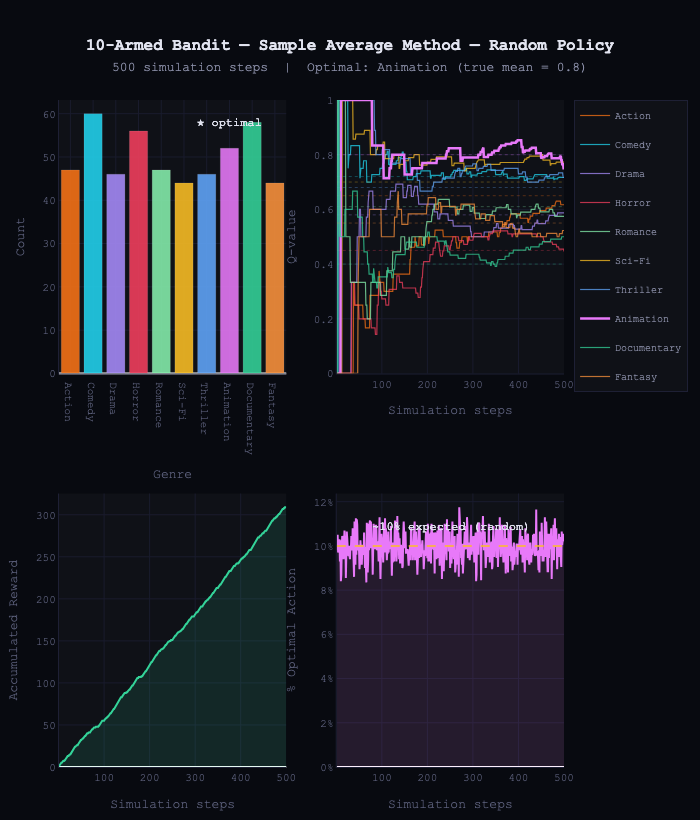


[1000 steps]
Final Q-values: [0.696969696969697, 0.7181818181818181, 0.4642857142857143, 0.39436619718309857, 0.69, 0.7428571428571429, 0.6831683168316832, 0.8529411764705882, 0.3977272727272727, 0.5535714285714286]
Count: [99, 110, 112, 71, 100, 105, 101, 102, 88, 112]
Accum Rewards: [69, 79, 52, 28, 69, 78, 69, 87, 35, 62]


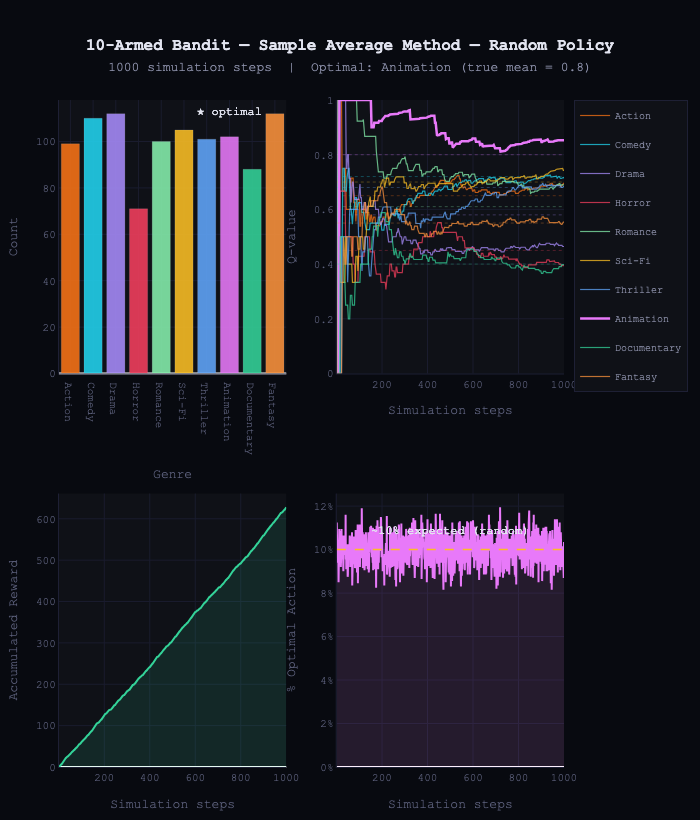


[5000 steps]
Final Q-values: [0.6367265469061876, 0.7541322314049587, 0.5853174603174603, 0.4576923076923077, 0.5970425138632163, 0.6820083682008368, 0.6873661670235546, 0.8234200743494424, 0.4024640657084189, 0.5729166666666666]
Count: [501, 484, 504, 520, 541, 478, 467, 538, 487, 480]
Accum Rewards: [319, 365, 295, 238, 323, 326, 321, 443, 196, 275]


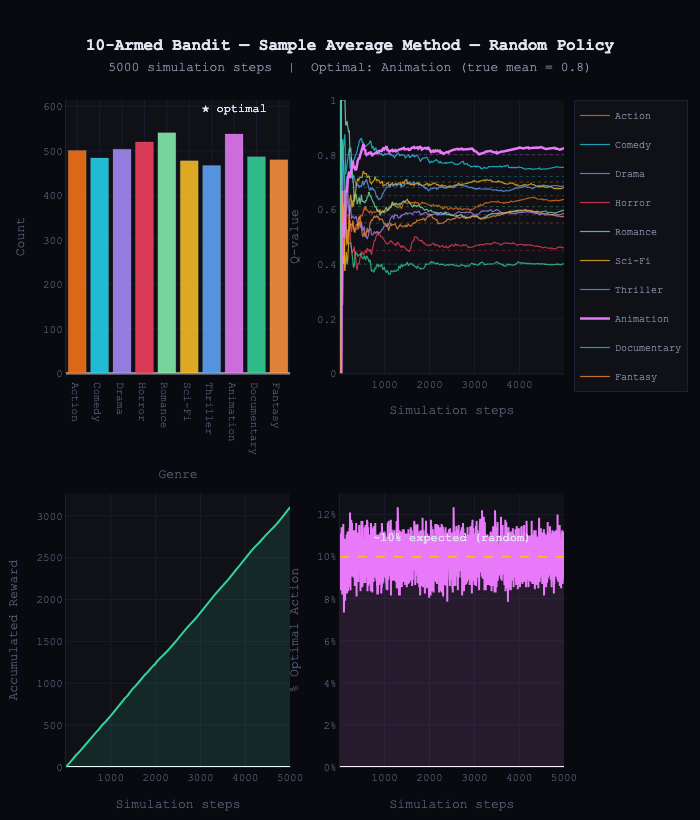


[10000 steps]
Final Q-values: [0.6206896551724138, 0.7265469061876247, 0.6126760563380281, 0.4553941908713693, 0.5784883720930233, 0.673890608875129, 0.6991404011461319, 0.8049281314168378, 0.39271255060728744, 0.5625615763546798]
Count: [1015, 1002, 994, 964, 1032, 969, 1047, 974, 988, 1015]
Accum Rewards: [630, 728, 609, 439, 597, 653, 732, 784, 388, 571]


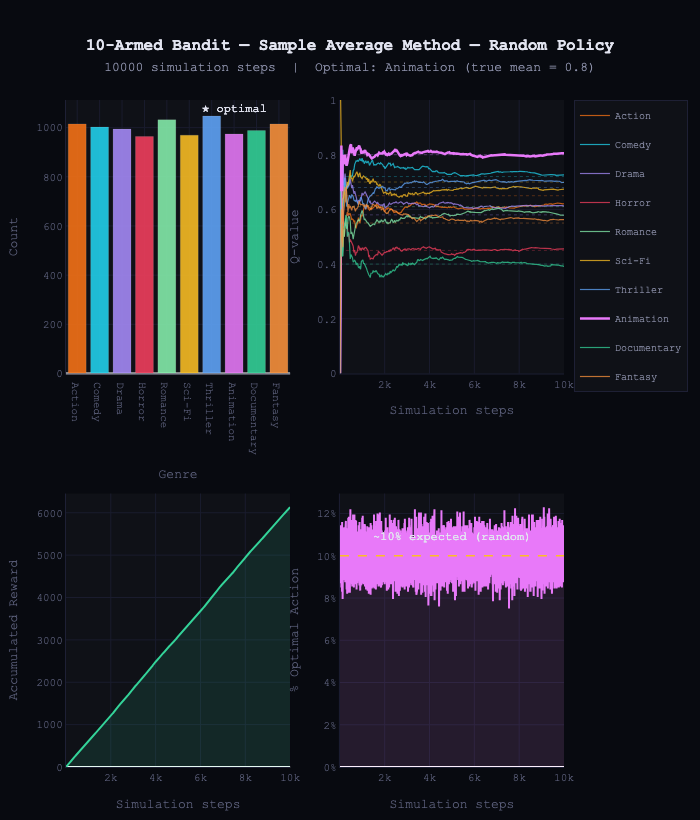

In [28]:
for steps in [500, 1000, 5000, 10000]:
    plot_scenario(steps)

### Interpretation

These charts show the performance of **Agent 1 (Random)** across four simulation horizons (500, 1000, 5000, and 10,000 steps).

**Plot a — Number of times each action was tried:**
With a random policy, each genre is selected uniformly. The bar chart shows an approximately even distribution, confirming the agent has no preference. The optimal action (Animation) is highlighted but receives no special treatment.

**Plot b — Q-value estimation over time:**
The estimated Q-values for each genre gradually converge toward their true means as more samples are collected. With more steps, the solid lines (agent estimates) approach true means hidden from the agent. However, convergence is slow because the agent wastes time on suboptimal actions.

**Plot c — Accumulated reward over time:**
The accumulated reward grows steadily and linearly across all scenarios. 

**Plot d — Percentage of optimal action (2000 runs):**
The percentage of times the optimal action (Animation) is selected hovers around 10%, which corresponds exactly to the probability of randomly picking one of 10 genres. This value does not converge toward the optimum with more steps, since a pure exploration policy has no learning mechanism.

**Conclusion:** The random policy serves as a baseline. Its accumulated reward and optimal selection rate are predictable but never improve, as the agent does not exploit information from past rewards.

---
## 3. Agent 2 — Greedy (Argmax, Pure Exploitation)

Now create your second agent, called greedy, which estimates action values using the argmax() function to exploit the action of greatest value (exploitation-only). You must present the following plots for 500, 1000, 5000 and 10000 simulation steps.
a. Numbers of times each action was tried.
b. Estimation of action values over time simulation steps.
c. Accumulated reward over time simulation steps.
d. Percentage of optimal action for 2000 runs.re.

In [29]:
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots


genre_actions = ["Action", "Comedy", "Drama", "Horror", "Romance",
                 "Sci-Fi", "Thriller", "Animation", "Documentary", "Fantasy"]

# Real World Simulation (Hidden Probabilities, Hidden Distributions)
# Hidden to the agent
true_means = [0.65, 0.72, 0.58, 0.45, 0.61, 0.70, 0.68, 0.80, 0.40, 0.55]

optimal_index = true_means.index(max(true_means))  # index 7 = Animation

COLORS = [
    "#f97316", "#22d3ee", "#a78bfa", "#f43f5e", "#86efac",
    "#fbbf24", "#60a5fa", "#e879f9", "#34d399", "#fb923c"
]






In [30]:
def simulate_greedy(steps):

    
    q_values     = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

    q_values_history  = []  
    acum_reward_total = []  
    total_reward      = 0

    for t in range(steps):

        
        selected_index = q_values.index(max(q_values))
        action = genre_actions[selected_index]

        
        if random.random() < true_means[selected_index]:
            reward = 1
        else:
            reward = 0

        counts[selected_index]       += 1
        acum_rewards[selected_index] += reward
        total_reward                 += reward

        # SAMPLE AVERAGE METHOD: Q(a) = acum_rewards(a) / counts(a)
       
        q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]

        q_values_history.append(q_values[:])
        acum_reward_total.append(total_reward)

    print(f"\n[Greedy — {steps} steps]")
    print(f"Final Q-values: {[round(q, 4) for q in q_values]}")
    print(f"Count: {counts}")
    print(f"Accum Rewards: {acum_rewards}")

    return q_values, counts, acum_rewards, q_values_history, acum_reward_total

In [31]:
def compute_optimal_pct_greedy(steps, n_runs=2000):
    optimal_counts = [0] * steps

    for _ in range(n_runs):
        
        q_values     = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

        for t in range(steps):
            selected_index = q_values.index(max(q_values))

            if random.random() < true_means[selected_index]:
                reward = 1
            else:
                reward = 0

            counts[selected_index]       += 1
            acum_rewards[selected_index] += reward
            q_values[selected_index]      = acum_rewards[selected_index] / counts[selected_index]

            if selected_index == optimal_index:
                optimal_counts[t] += 1

    return [c / n_runs * 100 for c in optimal_counts]





In [32]:
def plot_scenario_greedy(steps):
    q_values, counts, acum_rewards, q_values_history, acum_reward_total = simulate_greedy(steps)
    optimal_pct = compute_optimal_pct_greedy(steps)

    xs_accum = list(range(1, len(acum_reward_total) + 1))
    ys_accum = acum_reward_total
    xs_opt   = list(range(1, len(optimal_pct) + 1))
    ys_opt   = optimal_pct
    stride = max(1, steps // 300)
    xs_q   = list(range(1, steps + 1, stride))

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "a. Number of times each action was tried",
            "b. Estimation of action values over time",
            "c. Accumulated reward over time",
            "d. Percentage of optimal action (2000 runs)"
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10
    )

    # ── Plot a: Action counts ────────────────
    # With greedy + zero init we expect the agent to
    # try each action once or a few times at the start, then
    # keep exploiting the best one (Animation). This is why its bar
    # will have a much higher count than the rest.
    bar_colors = [
        "#e879f9" if i == optimal_index else COLORS[i]
        for i in range(len(genre_actions))
    ]
    fig.add_trace(go.Bar(
        x=genre_actions,
        y=counts,
        marker=dict(color=bar_colors, line=dict(color="rgba(255,255,255,0.13)", width=1), opacity=0.88),
        hovertemplate="<b>%{x}</b><br>Count: %{y}<extra></extra>",
        showlegend=False
    ), row=1, col=1)

    # ── Plot b: Q-value evolution ─────────────
    # At the start all Q-values begin at 0.
    # As the agent tries each action, they rise toward their true mean.
    # The dotted line shows the true mean hidden from the agent.
    for i, genre in enumerate(genre_actions):
        ys_q = [q_values_history[t][i] for t in range(0, steps, stride)]

        fig.add_trace(go.Scatter(
            x=xs_q, y=ys_q,
            mode="lines",
            name=genre,
            line=dict(color=COLORS[i], width=2.5 if i == optimal_index else 1.2),
            opacity=1 if i == optimal_index else 0.75,
            hovertemplate=f"<b>{genre}</b><br>Step: %{{x}}<br>Q: %{{y:.4f}}<extra></extra>",
            legendgroup=genre,
            showlegend=True
        ), row=1, col=2)

        # true mean (hidden from agent, visible to us)
        fig.add_trace(go.Scatter(
            x=[xs_q[0], xs_q[-1]],
            y=[true_means[i], true_means[i]],
            mode="lines",
            line=dict(color=COLORS[i], width=1, dash="dot"),
            opacity=0.3,
            hoverinfo="skip",
            legendgroup=genre,
            showlegend=False
        ), row=1, col=2)

    # ── Plot c: Accumulated reward ──────────────
    # The greedy agent should accumulate MORE reward than the random one
    # because it spends most of the time exploiting Animation (0.80),
    # the genre with the highest probability of a like.
    fig.add_trace(go.Scatter(
        x=xs_accum, y=ys_accum,
        mode="lines",
        name="Accum. Reward",
        line=dict(color="#34d399", width=2),
        fill="tozeroy",
        fillcolor="rgba(52, 211, 153, 0.12)",
        hovertemplate="Step: %{x}<br>Total Reward: %{y}<extra></extra>",
        showlegend=False
    ), row=2, col=1)

    # ── Plot d: % optimal action ───────────────────
    # Unlike the random agent (oscillates ~10% always),
    # the greedy agent should rise toward ~100% once it
    # identifies Animation as the best action and stays with it.
    fig.add_trace(go.Scatter(
        x=xs_opt, y=ys_opt,
        mode="lines",
        name="% Optimal",
        line=dict(color="#e879f9", width=2),
        fill="tozeroy",
        fillcolor="rgba(232, 121, 249, 0.10)",
        hovertemplate="Step: %{x}<br>Optimal: %{y:.2f}%<extra></extra>",
        showlegend=False
    ), row=2, col=2)

    # Reference line: 10% = what a random agent would achieve
    fig.add_trace(go.Scatter(
        x=[xs_opt[0], xs_opt[-1]], y=[10, 10],
        mode="lines",
        line=dict(color="#fbbf24", width=1.5, dash="dash"),
        hoverinfo="skip",
        showlegend=False
    ), row=2, col=2)

    # ── Layout and style ───────────────────────────
    fig.update_layout(
        title=dict(
            text=(
                f"<b>10-Armed Bandit — Greedy Agent — Optimistic Initialization</b><br>"
                f"<span style='font-size:13px;color:#8b8fa8'>"
                f"{steps} simulation steps &nbsp;|&nbsp; "
                f"Optimal: {genre_actions[optimal_index]} "
                f"(true mean = {true_means[optimal_index]})</span>"
            ),
            x=0.5, xanchor="center",
            font=dict(size=16, color="#e2e4f0")
        ),
        paper_bgcolor="#080a10",
        plot_bgcolor="#0f1117",
        font=dict(family="'Courier New', monospace", color="#8b8fa8", size=11),
        legend=dict(
            bgcolor="#0f1117", bordercolor="#1e2035", borderwidth=1,
            font=dict(size=10),
            itemclick="toggle",
            itemdoubleclick="toggleothers"
        ),
        height=820,
        margin=dict(t=100, b=40, l=50, r=30),
        hovermode="x unified",
        # NOTE: annotations use xref/yref instead of row/col
        # subplot 1 (top left)     → xref="x",  yref="y"
        # subplot 4 (bottom right) → xref="x4", yref="y4"
        annotations=[
            dict(
                x=genre_actions[optimal_index],
                y=counts[optimal_index],
                xref="x", yref="y",
                text="★ optimal",
                showarrow=False, yshift=16,
                font=dict(color="#e879f9", size=10)
            ),
            dict(
                x=xs_opt[len(xs_opt) // 2],
                y=10,
                xref="x4", yref="y4",
                text="~10% random baseline",
                showarrow=False, yshift=10,
                font=dict(color="#fbbf24", size=9)
            ),
        ]
    )

    for row, col in [(1,1),(1,2),(2,1),(2,2)]:
        fig.update_xaxes(gridcolor="#1a1c2e", linecolor="#1e2035",
                         tickfont=dict(color="#5b5f7a"), title_font=dict(color="#5b5f7a"),
                         row=row, col=col)
        fig.update_yaxes(gridcolor="#1a1c2e", linecolor="#1e2035",
                         tickfont=dict(color="#5b5f7a"), title_font=dict(color="#5b5f7a"),
                         row=row, col=col)

    fig.update_yaxes(range=[0, 1.1],  row=1, col=2)  # Q-values: start at 0, rise to true mean
    fig.update_yaxes(ticksuffix="%",  row=2, col=2)
    fig.update_xaxes(title_text="Genre",            row=1, col=1)
    fig.update_xaxes(title_text="Simulation steps", row=1, col=2)
    fig.update_xaxes(title_text="Simulation steps", row=2, col=1)
    fig.update_xaxes(title_text="Simulation steps", row=2, col=2)
    fig.update_yaxes(title_text="Count",             row=1, col=1)
    fig.update_yaxes(title_text="Q-value",           row=1, col=2)
    fig.update_yaxes(title_text="Accumulated Reward",row=2, col=1)
    fig.update_yaxes(title_text="% Optimal Action",  row=2, col=2)

    for ann in fig.layout.annotations:
        ann.font.color = "#e2e4f0"
        ann.font.size  = 12

    
    fig.show()





[Greedy — 500 steps]
Final Q-values: [0.662, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count: [500, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accum Rewards: [331, 0, 0, 0, 0, 0, 0, 0, 0, 0]


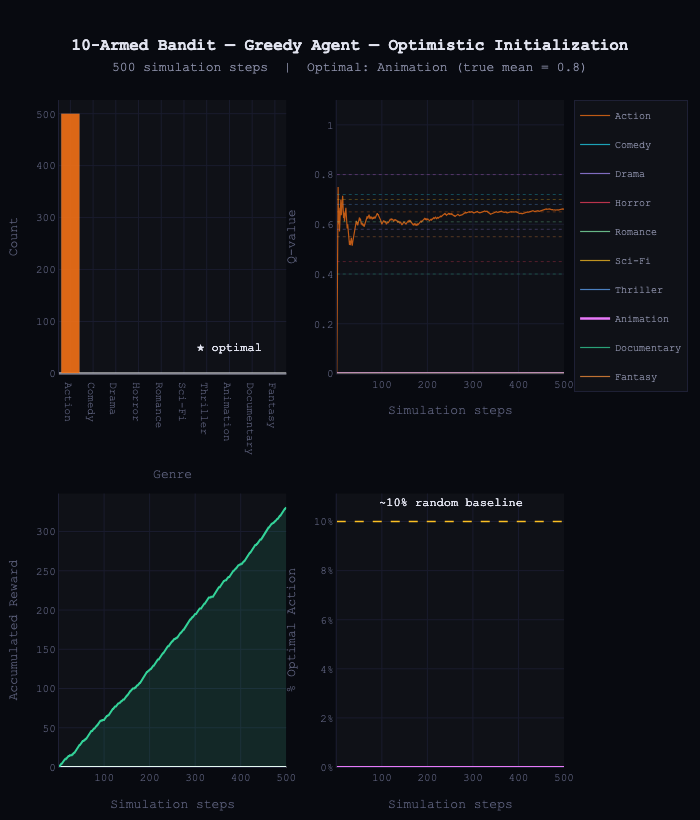


[Greedy — 1000 steps]
Final Q-values: [0.667, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count: [1000, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accum Rewards: [667, 0, 0, 0, 0, 0, 0, 0, 0, 0]


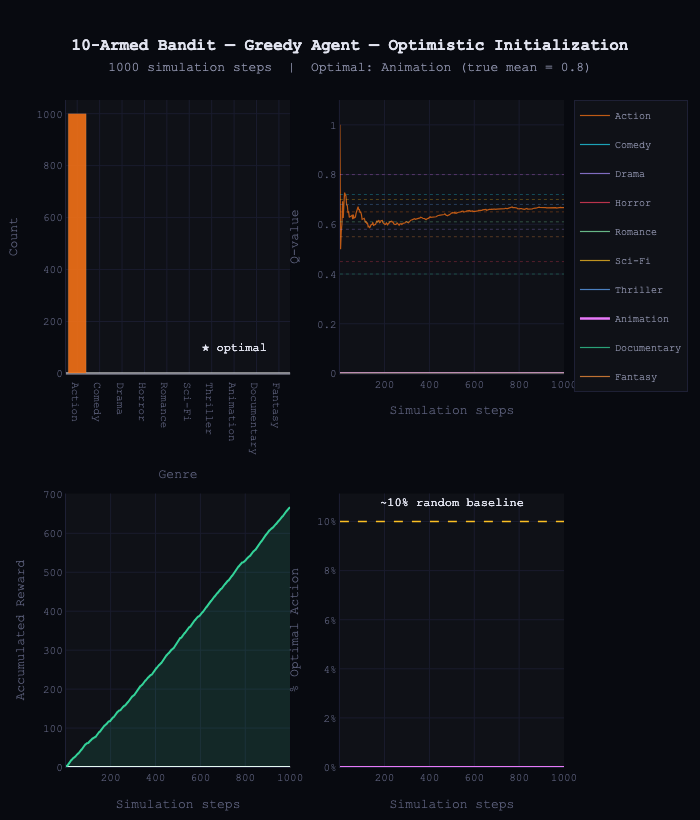


[Greedy — 5000 steps]
Final Q-values: [0.6484, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count: [5000, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accum Rewards: [3242, 0, 0, 0, 0, 0, 0, 0, 0, 0]


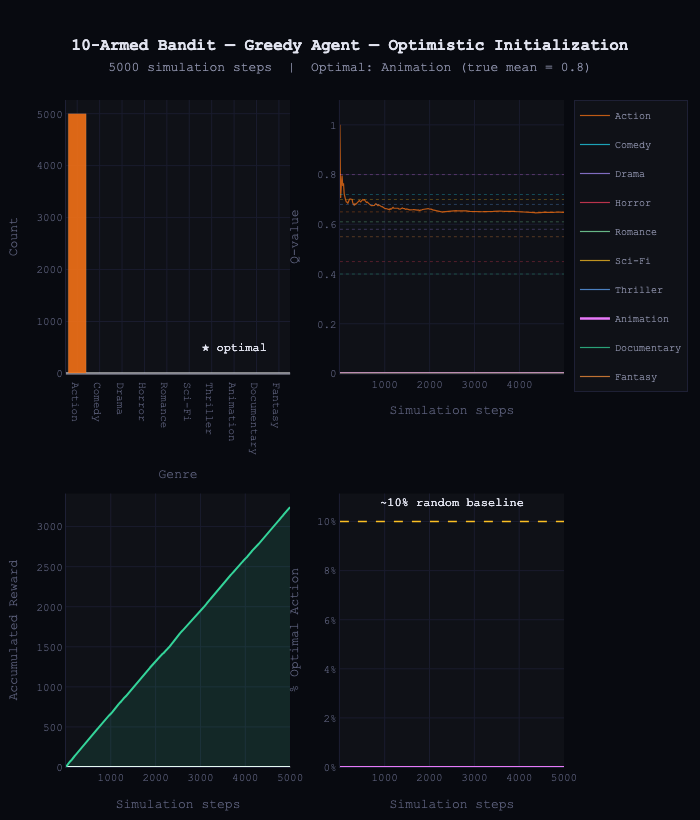


[Greedy — 10000 steps]
Final Q-values: [0.6446, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count: [10000, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accum Rewards: [6446, 0, 0, 0, 0, 0, 0, 0, 0, 0]


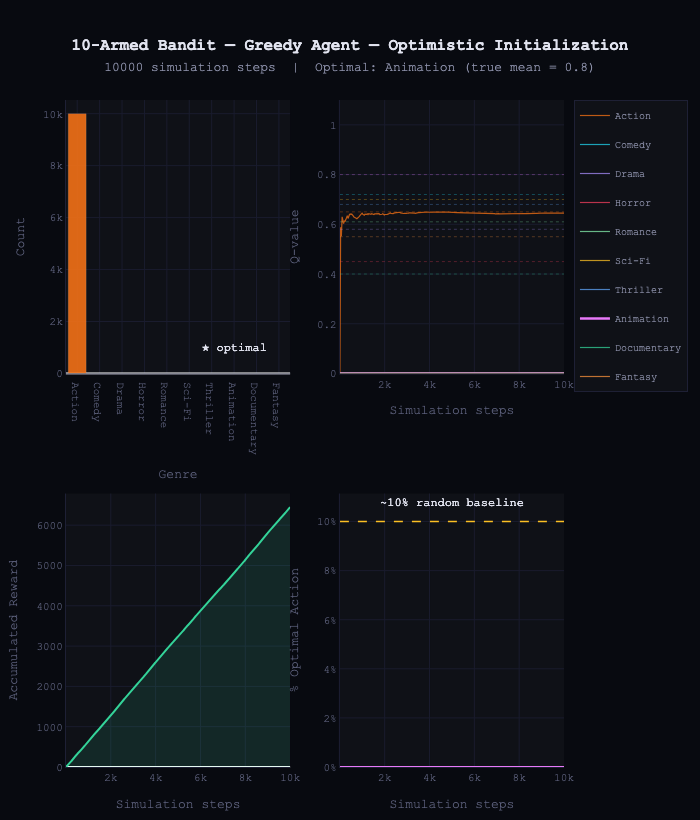

In [33]:

for steps in [500, 1000, 5000, 10000]:
    plot_scenario_greedy(steps)

### Interpretation

These charts illustrate the behavior of **Agent 2 (Greedy / Argmax)** across four simulation scenarios.

**Plot a — Number of times each action was tried:**
The bar chart is highly unbalanced: one genre dominates all selections while the rest were never tried. This is a direct consequence of pure exploitation with zero initialization, the agent committed to the very first action it tried from the beginning and never deviated from it for the remainder of the simulation.

**Plot b — Q-value estimation over time:**
Only the exploited genre's Q-value converges reliably toward its true mean.

**Plot c — Accumulated reward over time:**
The accumulated reward grows linearly, but the slope depends on which genre the agent gets "locked into" after the initial exploration. If it converges to Animation (μ = 0.80), it outperforms the random agent. If it gets trapped in a suboptimal genre, it performs worse.

**Plot d — Percentage of optimal action (2000 runs):**
Remained at 0% throughout the simulation, as the agent never selected the optimal action after committing to its initial choice.

**Conclusion:** The greedy agent is more efficient than the random one when it successfully identifies the optimum, but it is fragile when gets trapped in local maxima. Its lack of exploration makes it sensitive to initial rewards, resulting in inconsistent performance across runs, in this case the agent just tried one action.

---
## 4. Comparative Framework — Greedy with Different Initializations

Make a comparative framework of the performance of your greedy agent when the action values are initialized in different ways: at zero, randomly, and optimistically. Choose a fixed simulation step.
a. Numbers of times each action was tried.
b. Estimation of action values over time simulation steps.
c. Accumulated reward over time simulation steps.
d. Percentage of optimal action for 2000 runs.

Note: For an optimistic initialization, it is suggested that the initial value should be greater than any possible reward in the distribution. Example: rewards between 0 and 1, initialize at q = 5. The aim of this is to ensure that the agent's values remain optimistic as it progresses through the simulation steps.

### Zero initialization

In [34]:
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots

genre_actions = ["Action", "Comedy", "Drama", "Horror", "Romance",
                 "Sci-Fi", "Thriller", "Animation", "Documentary", "Fantasy"]

true_means = [0.65, 0.72, 0.58, 0.45, 0.61, 0.70, 0.68, 0.80, 0.40, 0.55]

optimal_index = true_means.index(max(true_means))

STEPS = 1000

# --- Zero initialization ---
random.seed(42)
q_values     = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

q_hist_z = []
cum_z    = []
total_reward = 0

for t in range(STEPS):

    selected_index = q_values.index(max(q_values))
    action = genre_actions[selected_index]

    if random.random() < true_means[selected_index]:
        reward = 1
    else:
        reward = 0

    counts[selected_index]       += 1
    acum_rewards[selected_index] += reward
    total_reward                 += reward

    q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]

    q_hist_z.append(q_values[:])
    cum_z.append(total_reward)

counts_z = counts[:]

print(f"\n[Zero Init — {STEPS} steps]")
print(f"Final Q-values: {[round(q, 4) for q in q_values]}")
print(f"Count: {counts_z}")
print(f"Accum Rewards: {acum_rewards}")


[Zero Init — 1000 steps]
Final Q-values: [0.637, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count: [1000, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accum Rewards: [637, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [35]:
def compute_optimal_pct_zero(steps, n_runs=2000):
    optimal_counts = [0] * steps
    for run in range(n_runs):
        q_values     = [0]*10
        counts       = [0]*10
        acum_rewards = [0]*10
        for t in range(steps):
            selected_index = q_values.index(max(q_values))
            if random.random() < true_means[selected_index]:
                reward = 1
            else:
                reward = 0
            counts[selected_index]       += 1
            acum_rewards[selected_index] += reward
            q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]
            if selected_index == optimal_index:
                optimal_counts[t] += 1
    return [c / n_runs * 100 for c in optimal_counts]

pct_z = compute_optimal_pct_zero(STEPS)
print("Zero — % optimal computed.")

Zero — % optimal computed.


### Random initialization

In [36]:
# --- Random initialization ---
random.seed(42)
q_values     = [random.random() for _ in range(10)]
counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

q_hist_r = []
cum_r    = []
total_reward = 0

for t in range(STEPS):

    selected_index = q_values.index(max(q_values))
    action = genre_actions[selected_index]

    if random.random() < true_means[selected_index]:
        reward = 1
    else:
        reward = 0

    counts[selected_index]       += 1
    acum_rewards[selected_index] += reward
    total_reward                 += reward

    q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]

    q_hist_r.append(q_values[:])
    cum_r.append(total_reward)

counts_r = counts[:]

print(f"\n[Random Init — {STEPS} steps]")
print(f"Final Q-values: {[round(q, 4) for q in q_values]}")
print(f"Count: {counts_r}")
print(f"Accum Rewards: {acum_rewards}")


[Random Init — 1000 steps]
Final Q-values: [0.6394, 0.025, 0.275, 0.2232, 0.5714, 0.5, 0.6714, 0.0869, 0.4219, 0.0298]
Count: [0, 0, 0, 0, 7, 4, 989, 0, 0, 0]
Accum Rewards: [0, 0, 0, 0, 4, 2, 664, 0, 0, 0]


In [37]:
def compute_optimal_pct_random(steps, n_runs=2000):
    optimal_counts = [0] * steps
    for run in range(n_runs):
        q_values     = [random.random() for _ in range(10)]
        counts       = [0]*10
        acum_rewards = [0]*10
        for t in range(steps):
            selected_index = q_values.index(max(q_values))
            if random.random() < true_means[selected_index]:
                reward = 1
            else:
                reward = 0
            counts[selected_index]       += 1
            acum_rewards[selected_index] += reward
            q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]
            if selected_index == optimal_index:
                optimal_counts[t] += 1
    return [c / n_runs * 100 for c in optimal_counts]

pct_r = compute_optimal_pct_random(STEPS)
print("Random — % optimal computed.")

Random — % optimal computed.


### Optimistic initialization

In [38]:
# --- Optimistic initialization (Q₀ = 500) ---

q_values     = [500]*10
counts       = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
acum_rewards = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

q_hist_o = []
cum_o    = []
total_reward = 0

for t in range(STEPS):

    selected_index = q_values.index(max(q_values))
    action = genre_actions[selected_index]

    if random.random() < true_means[selected_index]:
        reward = 1
    else:
        reward = 0

    counts[selected_index]       += 1
    acum_rewards[selected_index] += reward
    total_reward                 += reward

    q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]

    # Use None for genres not yet selected — avoids 20000 artifacts in [0,1] chart
    q_hist_o.append([q_values[j] if counts[j] > 0 else None for j in range(10)])
    cum_o.append(total_reward)

counts_o = counts[:]

print(f"\n[Optimistic Init Q₀=500 — {STEPS} steps]")
print(f"Final Q-values: {[round(q, 4) for q in q_values]}")
print(f"Count: {counts_o}")
print(f"Accum Rewards: {acum_rewards}")


[Optimistic Init Q₀=500 — 1000 steps]
Final Q-values: [0.5, 0.625, 0.0, 0.0, 0.625, 0.6975, 0.5, 0.6667, 0.5, 0.0]
Count: [2, 8, 1, 1, 8, 972, 2, 3, 2, 1]
Accum Rewards: [1, 5, 0, 0, 5, 678, 1, 2, 1, 0]


In [39]:
def compute_optimal_pct_optimistic(steps, n_runs=2000):
    optimal_counts = [0] * steps
    for run in range(n_runs):
        q_values     = [500]*10
        counts       = [0]*10
        acum_rewards = [0]*10
        for t in range(steps):
            selected_index = q_values.index(max(q_values))
            if random.random() < true_means[selected_index]:
                reward = 1
            else:
                reward = 0
            counts[selected_index]       += 1
            acum_rewards[selected_index] += reward
            q_values[selected_index] = acum_rewards[selected_index] / counts[selected_index]
            if selected_index == optimal_index:
                optimal_counts[t] += 1
    return [c / n_runs * 100 for c in optimal_counts]

pct_o = compute_optimal_pct_optimistic(STEPS)
print("Optimistic — % optimal computed.")

Optimistic — % optimal computed.


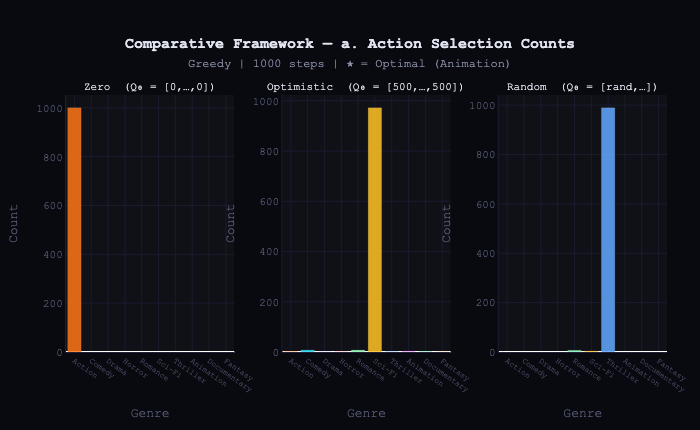

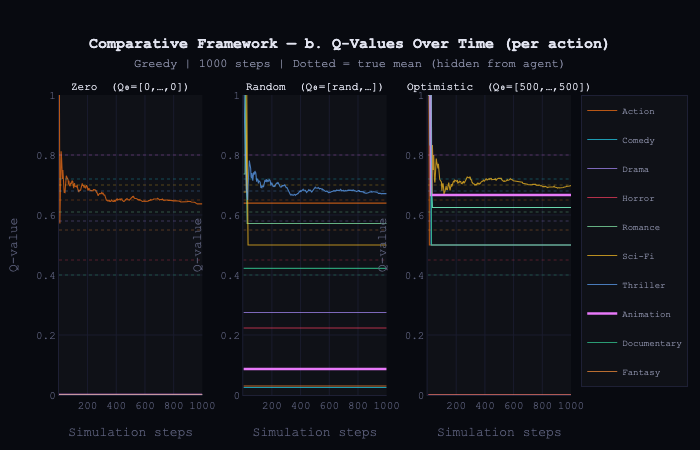

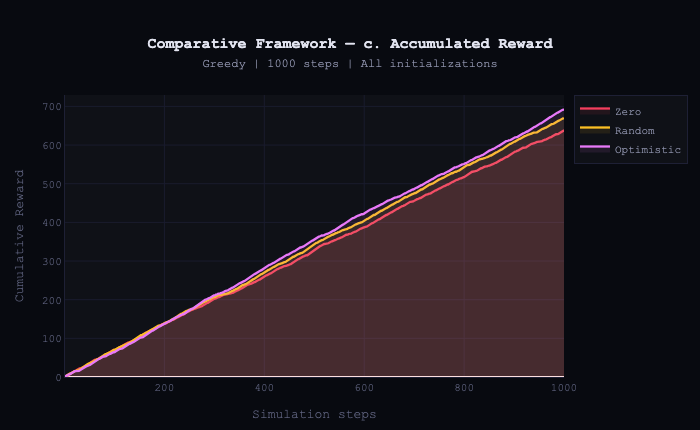

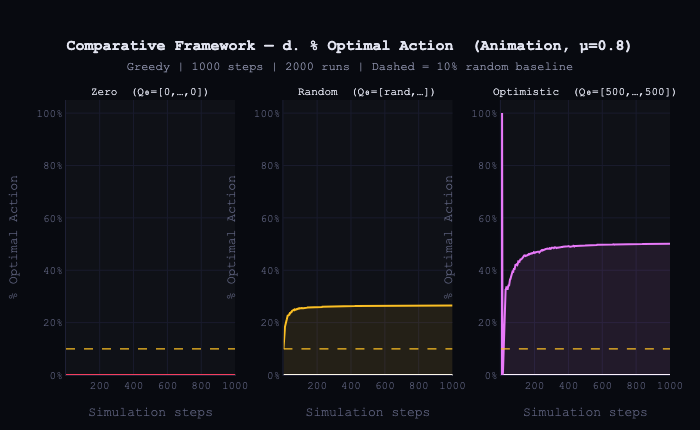

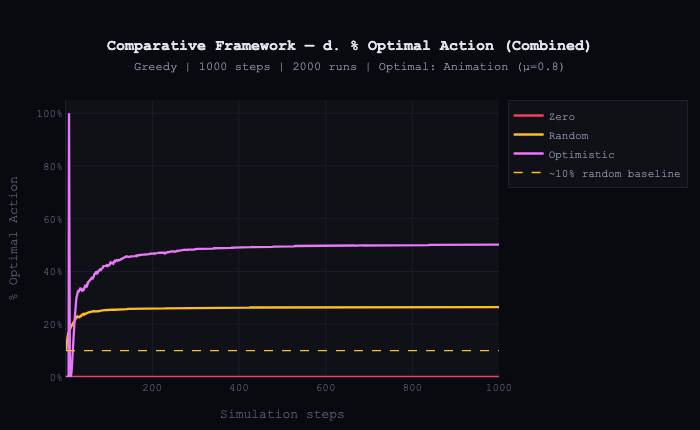

In [40]:
# COMPARATIVE FRAMEWORK — Visualizations (a · b · c · d)
#
# Uses data already computed by the agent cells above:
#   counts_z / q_hist_z / cum_z / pct_z  ← Zero initialization
#   counts_r / q_hist_r / cum_r / pct_r  ← Random initialization
#   counts_o / q_hist_o / cum_o / pct_o  ← Optimistic initialization (Q₀=500)
#
#  Fig 1 — Count bar charts        (3 subplots: Zero | Optimistic | Random)
#  Fig 2 — Q-values over time      (3 subplots: Zero | Random    | Optimistic)
#  Fig 3 — Accumulated reward      (1 graph, 3 lines)
#  Fig 4 — % Optimal action        (3 subplots: Zero | Random    | Optimistic)
#  Fig 5 — % Optimal (combined)    (1 graph, 3 lines)

import plotly.graph_objects as go
from plotly.subplots import make_subplots

steps_x = list(range(1, STEPS + 1))
stride  = max(1, STEPS // 300)
xs_q    = list(range(1, STEPS + 1, stride))

COLORS = [
    "#f97316", "#22d3ee", "#a78bfa", "#f43f5e", "#86efac",
    "#fbbf24", "#60a5fa", "#e879f9", "#34d399", "#fb923c"
]
INIT_COLORS = {"Zero": "#f43f5e", "Random": "#fbbf24", "Optimistic": "#e879f9"}
FILL_COLORS = {
    "Zero":       "rgba(244,63,94,0.09)",
    "Random":     "rgba(251,191,36,0.09)",
    "Optimistic": "rgba(232,121,249,0.09)",
}

_AXIS = dict(gridcolor="#1a1c2e", linecolor="#1e2035",
             title_font=dict(color="#5b5f7a"))
_TICKFONT    = dict(color="#5b5f7a")
_TICKFONT_SM = dict(color="#5b5f7a", size=8)
_LAYOUT = dict(paper_bgcolor="#080a10", plot_bgcolor="#0f1117",
               font=dict(family="'Courier New', monospace", color="#8b8fa8", size=11))


# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — a. Count bar charts
# ══════════════════════════════════════════════════════════════════════
fig1 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "Zero  (Q₀ = [0,…,0])",
        "Optimistic  (Q₀ = [500,…,500])",
        "Random  (Q₀ = [rand,…])",
    ],
    horizontal_spacing=0.08,
)
for col, (counts, _) in enumerate(
    [(counts_z, "Zero"), (counts_o, "Optimistic"), (counts_r, "Random")], start=1
):
    bc = ["#e879f9" if i == optimal_index else COLORS[i] for i in range(10)]
    fig1.add_trace(go.Bar(
        x=genre_actions, y=counts,
        marker=dict(color=bc, opacity=0.88,
                    line=dict(color="rgba(255,255,255,0.1)", width=1)),
        hovertemplate="<b>%{x}</b><br>Count: %{y}<extra></extra>",
        showlegend=False,
    ), row=1, col=col)

fig1.update_layout(
    **_LAYOUT,
    title=dict(
        text=(f"<b>Comparative Framework — a. Action Selection Counts</b><br>"
              f"<span style='font-size:12px;color:#8b8fa8'>"
              f"Greedy | {STEPS} steps | ★ = Optimal ({genre_actions[optimal_index]})</span>"),
        x=0.5, xanchor="center", font=dict(size=15, color="#e2e4f0"),
    ),
    height=430, margin=dict(t=95, b=55, l=50, r=30),
)
for col in [1, 2, 3]:
    fig1.update_xaxes(**_AXIS, tickfont=_TICKFONT_SM, tickangle=35,
                      title_text="Genre", row=1, col=col)
    fig1.update_yaxes(**_AXIS, tickfont=_TICKFONT, title_text="Count", row=1, col=col)
for ann in fig1.layout.annotations:
    ann.font.color = "#e2e4f0"; ann.font.size = 11
fig1.show()


# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — b. Q-values per action over time
# ══════════════════════════════════════════════════════════════════════
fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "Zero  (Q₀=[0,…,0])",
        "Random  (Q₀=[rand,…])",
        "Optimistic  (Q₀=[500,…,500])",
    ],
    horizontal_spacing=0.08,
)
for col, (q_hist, _) in enumerate(
    [(q_hist_z, "Zero"), (q_hist_r, "Random"), (q_hist_o, "Optimistic")], start=1
):
    for i, genre in enumerate(genre_actions):
        ys = [q_hist[t][i] for t in range(0, STEPS, stride)]
        fig2.add_trace(go.Scatter(
            x=xs_q, y=ys, mode="lines", name=genre,
            line=dict(color=COLORS[i], width=2.5 if i == optimal_index else 1.1),
            opacity=1.0 if i == optimal_index else 0.72,
            hovertemplate=f"<b>{genre}</b><br>Step: %{{x}}<br>Q: %{{y:.4f}}<extra></extra>",
            legendgroup=genre, showlegend=(col == 1),
        ), row=1, col=col)
        fig2.add_trace(go.Scatter(
            x=[xs_q[0], xs_q[-1]], y=[true_means[i], true_means[i]], mode="lines",
            line=dict(color=COLORS[i], width=1, dash="dot"),
            opacity=0.3, hoverinfo="skip", legendgroup=genre, showlegend=False,
        ), row=1, col=col)

fig2.update_layout(
    **_LAYOUT,
    title=dict(
        text=(f"<b>Comparative Framework — b. Q-Values Over Time (per action)</b><br>"
              f"<span style='font-size:12px;color:#8b8fa8'>"
              f"Greedy | {STEPS} steps | Dotted = true mean (hidden from agent)</span>"),
        x=0.5, xanchor="center", font=dict(size=15, color="#e2e4f0"),
    ),
    legend=dict(bgcolor="#0f1117", bordercolor="#1e2035", borderwidth=1,
                font=dict(size=9), itemclick="toggle", itemdoubleclick="toggleothers"),
    height=450, margin=dict(t=95, b=55, l=50, r=30),
    hovermode="x unified",
)
for col in [1, 2, 3]:
    fig2.update_xaxes(**_AXIS, tickfont=_TICKFONT, title_text="Simulation steps", row=1, col=col)
    fig2.update_yaxes(**_AXIS, tickfont=_TICKFONT, title_text="Q-value", row=1, col=col)
# Fix: clamp all 3 subplots to [0, 1] so Q-value convergence is visible
fig2.update_yaxes(range=[0, 1], row=1, col=1)
fig2.update_yaxes(range=[0, 1], row=1, col=2)
fig2.update_yaxes(range=[0, 1], row=1, col=3)  # col=3 (Optimistic): must clamp — Q₀=20000 would hide all [0,1] evolution
for ann in fig2.layout.annotations:
    ann.font.color = "#e2e4f0"; ann.font.size = 11
fig2.show()


# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — c. Accumulated reward (3 lines on same graph)
# ══════════════════════════════════════════════════════════════════════
fig3 = go.Figure()
# Zero is added first (drawn at the bottom); add fill so it stays visible
# even when Random and Optimistic lines are close in value.
for name, cum in [("Zero", cum_z), ("Random", cum_r), ("Optimistic", cum_o)]:
    fig3.add_trace(go.Scatter(
        x=steps_x, y=cum, mode="lines", name=name,
        line=dict(color=INIT_COLORS[name], width=2.3),
        fill="tozeroy",
        fillcolor=FILL_COLORS[name],
        hovertemplate=f"<b>{name}</b><br>Step: %{{x}}<br>Reward: %{{y}}<extra></extra>",
    ))
fig3.update_layout(
    **_LAYOUT,
    title=dict(
        text=(f"<b>Comparative Framework — c. Accumulated Reward</b><br>"
              f"<span style='font-size:12px;color:#8b8fa8'>"
              f"Greedy | {STEPS} steps | All initializations</span>"),
        x=0.5, xanchor="center", font=dict(size=15, color="#e2e4f0"),
    ),
    legend=dict(bgcolor="#0f1117", bordercolor="#1e2035", borderwidth=1, font=dict(size=11)),
    xaxis=dict(**_AXIS, tickfont=_TICKFONT, title_text="Simulation steps"),
    yaxis=dict(**_AXIS, tickfont=_TICKFONT, title_text="Cumulative Reward"),
    height=430, margin=dict(t=95, b=50, l=65, r=30),
    hovermode="x unified",
)
fig3.show()


# ══════════════════════════════════════════════════════════════════════
# FIGURE 4 — d. % Optimal action — 3 separate subplots
# ══════════════════════════════════════════════════════════════════════
fig4 = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "Zero  (Q₀=[0,…,0])",
        "Random  (Q₀=[rand,…])",
        "Optimistic  (Q₀=[500,…,500])",
    ],
    horizontal_spacing=0.08,
)
for col, (name, pct) in enumerate(
    [("Zero", pct_z), ("Random", pct_r), ("Optimistic", pct_o)], start=1
):
    fig4.add_trace(go.Scatter(
        x=steps_x, y=pct, mode="lines", name=name,
        line=dict(color=INIT_COLORS[name], width=2),
        fill="tozeroy", fillcolor=FILL_COLORS[name],
        hovertemplate=f"<b>{name}</b><br>Step: %{{x}}<br>% Optimal: %{{y:.2f}}%<extra></extra>",
        showlegend=False,
    ), row=1, col=col)
    fig4.add_trace(go.Scatter(
        x=[steps_x[0], steps_x[-1]], y=[10, 10], mode="lines",
        line=dict(color="#fbbf24", width=1.2, dash="dash"),
        hoverinfo="skip", showlegend=False,
    ), row=1, col=col)

fig4.update_layout(
    **_LAYOUT,
    title=dict(
        text=(f"<b>Comparative Framework — d. % Optimal Action  "
              f"({genre_actions[optimal_index]}, μ={true_means[optimal_index]})</b><br>"
              f"<span style='font-size:12px;color:#8b8fa8'>"
              f"Greedy | {STEPS} steps | 2000 runs | Dashed = 10% random baseline</span>"),
        x=0.5, xanchor="center", font=dict(size=15, color="#e2e4f0"),
    ),
    height=430, margin=dict(t=100, b=55, l=55, r=30),
    hovermode="x unified",
)
for col in [1, 2, 3]:
    fig4.update_xaxes(**_AXIS, tickfont=_TICKFONT, title_text="Simulation steps", row=1, col=col)
    fig4.update_yaxes(**_AXIS, tickfont=_TICKFONT, title_text="% Optimal Action",
                      ticksuffix="%", range=[0, 105], row=1, col=col)
for ann in fig4.layout.annotations:
    ann.font.color = "#e2e4f0"; ann.font.size = 11
fig4.show()


# ══════════════════════════════════════════════════════════════════════
# FIGURE 5 — d. % Optimal action — Combined (3 initializations, 1 graph)
# ══════════════════════════════════════════════════════════════════════
fig5 = go.Figure()
for name, pct in [("Zero", pct_z), ("Random", pct_r), ("Optimistic", pct_o)]:
    fig5.add_trace(go.Scatter(
        x=steps_x, y=pct, mode="lines", name=name,
        line=dict(color=INIT_COLORS[name], width=2.3),
        hovertemplate=f"<b>{name}</b><br>Step: %{{x}}<br>% Optimal: %{{y:.2f}}%<extra></extra>",
    ))
fig5.add_trace(go.Scatter(
    x=[steps_x[0], steps_x[-1]], y=[10, 10], mode="lines",
    name="~10% random baseline",
    line=dict(color="#fbbf24", width=1.3, dash="dash"),
    hoverinfo="skip",
))
fig5.update_layout(
    **_LAYOUT,
    title=dict(
        text=(f"<b>Comparative Framework — d. % Optimal Action (Combined)</b><br>"
              f"<span style='font-size:12px;color:#8b8fa8'>"
              f"Greedy | {STEPS} steps | 2000 runs | "
              f"Optimal: {genre_actions[optimal_index]} (μ={true_means[optimal_index]})</span>"),
        x=0.5, xanchor="center", font=dict(size=15, color="#e2e4f0"),
    ),
    legend=dict(bgcolor="#0f1117", bordercolor="#1e2035", borderwidth=1, font=dict(size=11)),
    xaxis=dict(**_AXIS, tickfont=_TICKFONT, title_text="Simulation steps"),
    yaxis=dict(**_AXIS, tickfont=_TICKFONT, title_text="% Optimal Action",
               ticksuffix="%", range=[0, 105]),
    height=430, margin=dict(t=100, b=50, l=65, r=30),
    hovermode="x unified",
)
fig5.show()

### Interpretation

The same greedy agent was tested starting from three different initial value configurations.

**Zero initialization:** The agent always committed to the first action tried, never deviating from it for the remainder of the simulation.

**Random initialization:** There was some initial exploration due to the variability in starting values; however, the agent selected the same action in the following steps.

**Optimistic initialization:** The agent visited all actions before committing, since the overestimated initial values encouraged early exploration. However, it did not converge to the optimal action (Animation, μ=0.80), but rather to a genre with a high true value (Science Fiction, μ=0.70). 


**Section d: % Optimal Action (Initialization Comparison)**
The graph shows the percentage of runs (over 2000 runs) in which each variant of the greedy agent selected the optimal action (Animation, μ=0.80) across 1000 simulation steps.

**Zero initialization (red):** the agent got stuck from the very first step on the same action, which was not the optimal one, resulting in a 0% optimal action rate throughout the entire simulation. This confirms the core problem of the pure greedy agent: without any initial exploration, it permanently commits to the first action it tries and never discovers that better options exist.

**Random initialization (yellow):** starts near 10% (similar to random selection) and rises quickly, stabilizing around 26-27% from step 200 onwards and remaining there until the end. The variability in initial values allowed a fraction of the 2000 runs to explore enough to find Animation, but most converged prematurely to suboptimal genres.

**Optimistic initialization (pink):** is clearly the best of the three. It begins at 100% during the first steps because all values are overestimated, which forces the agent to try every action before committing. It then drops and gradually rises as runs converge, stabilizing near 50% toward the end. This means that approximately half of the 2000 runs successfully identified and exploited the optimal action, which is a significantly superior result compared to the other two initializations.
In conclusion, optimistic initialization proves to be the most effective strategy for this scenario, as it incorporates exploration implicitly without requiring an explicit ε parameter, achieving nearly double the optimal selections compared to random initialization and being infinitely superior to zero initialization.